In [1]:

import os
import math
import time
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import torch
import torch.nn.functional as F  
from torch.utils.tensorboard import SummaryWriter

from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADDomainVisualizer import CADDomainVisualizer
from Utils.CADVisualizer   import CADVisualizer
from neuraltomo_fem import run_fem_loss
from problems.ThickenShell import ThickenShell
from Training.MainTrain import NN_Trainer, TrainingConfig
from Decoder_CLasses.ContinuousVoronoiDecoder import ContinuousVoronoiDecoder
from Pred_NN_Classes.ppnet import PPNet
from scipy.spatial import Delaunay, Voronoi, voronoi_plot_2d, cKDTree,QhullError

import pyvista as pv


# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)


if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
# -------- PYVISTA BACKEND --------
def setup_pyvista(device):
    is_mac = sys.platform == "darwin"

    # Mac + MPS: prefer static to avoid VTK/trame hangs
    if is_mac :
        pv.OFF_SCREEN = True
        pv.set_jupyter_backend("static")
        backend = "static"
    else:
        try:
            pv.set_jupyter_backend("trame")
            backend = "trame"
        except Exception:
            pv.OFF_SCREEN = True
            pv.set_jupyter_backend("static")
            backend = "static"

    print(f"PyVista backend: {backend}")

setup_pyvista(device)

%matplotlib inline
def random_seeds_min_dist(N, min_dist=0.08, seed=1, max_tries=10000, device="cpu"):
    torch.manual_seed(seed)

    seeds = []
    tries = 0

    while len(seeds) < N and tries < max_tries:
        p = torch.rand(2, device=device)

        if len(seeds) == 0:
            seeds.append(p)
        else:
            current = torch.stack(seeds, dim=0)
            d = torch.linalg.norm(current - p[None, :], dim=-1)

            if d.min() >= min_dist:
                seeds.append(p)

        tries += 1

    if len(seeds) < N:
        raise RuntimeError(
            f"Could only generate {len(seeds)} seeds with min_dist={min_dist}."
        )

    return torch.stack(seeds, dim=0)

Code Directory: /home/arash/HVD_SeedsBase
Test Step files Directory: /home/arash/HVD_SeedsBase/Testparts
device: cuda
PyVista backend: trame


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    :  - Label 'Shapes/Document' (2D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (BSpline)
Info    : [ 30%] Meshing curve 2 (BSpline)
Info    : [ 60%] Meshing curve 3 (BSpline)
Info    : [ 80%] Meshing curve 4 (BSpline)
Info    : Done meshing 1D (Wall 0.000501197s, CPU 0.000558s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.607947s, CPU 0.595973s)
Info    : 35669 nodes 71340 elements
Info    : Clearing all models and views...
Info    : Done clearing all models and views

=== Active Face Info ===
XYZ bounds:
  X: [-0.000000, 10.000000]  span=10.000000
  Y: [-0.000000, 10.000000]  span=10.000000
  Z: [-0.000000, 0.000000]  span=0.000000

UV bounds:
  U: [-10.000000, 0.000000]
  V: [0.000000, 10.000000]

Periodic:
  U periodic: False
  V periodic: False



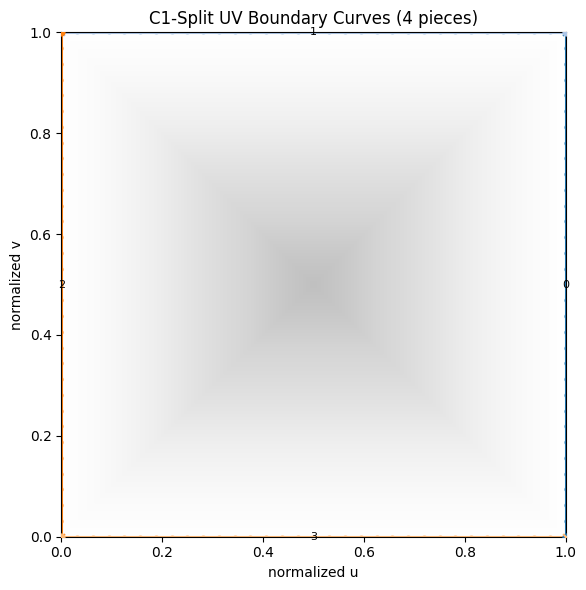

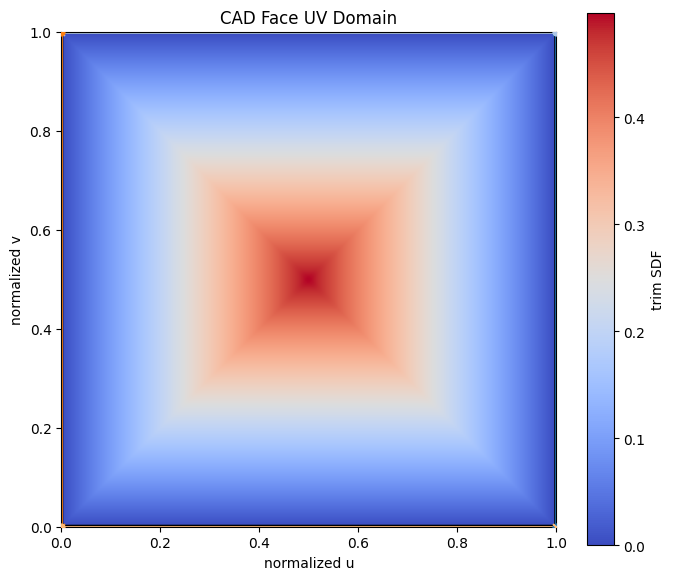

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d8567e1750_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d8566d0610_1&reconnect=auto" class="pyvi…

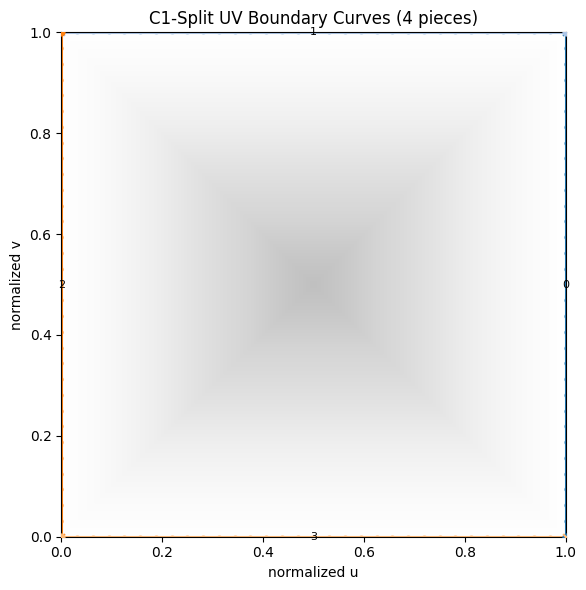

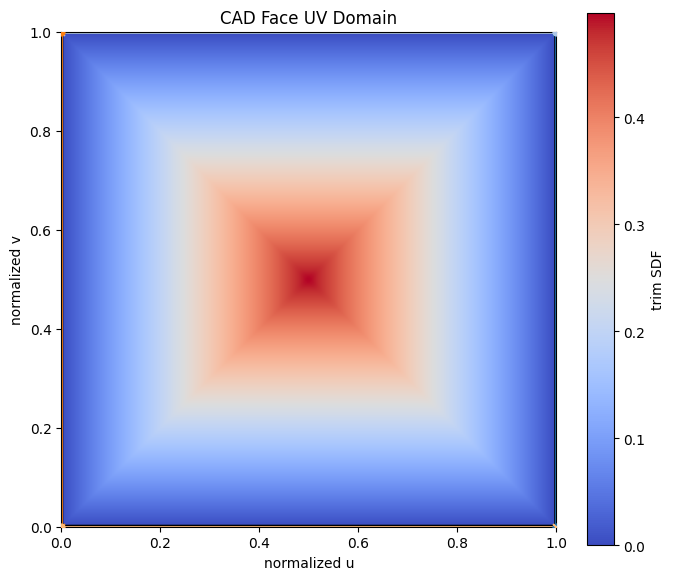

 JS Error => TypeError: Cannot create proxy with a non-object as target or handler


In [ ]:
viz = CADVisualizer()
DoTests = True 
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
FreeFormSurf3 = TesPartsDir / "FreeForm3.stp"
ConeTaped = TesPartsDir / "ConeTaped.stp"
FreeFormCLosed = TesPartsDir / "FreeFormClosed.stp"
Planar = TesPartsDir / "Planar.stp"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"
FreeFormSurf4 = TesPartsDir / "FreeForm4.stp"
FreeFormBench = TesPartsDir / "FreeFormBench.stp"
FreeSharp1 = TesPartsDir / "FreeSharp1.stp"
FreeSharp2 = TesPartsDir / "FreeSharp2.stp"
SeatBr = TesPartsDir / "SeatBr.stp"
MouseBot = TesPartsDir / "MouseBot.stp"

shape_path = Planar

Face_Cad = CADTensorGenerator(
    device=device,
    seed_domain_mask_res=512,
    mesh_size_scale = 0.3,
)

cad_domain, face_mesh = Face_Cad.generate_from_file(shape_path)

dx,dy,dz = Face_Cad.print_face_info();

viz = CADDomainVisualizer(Face_Cad)
fig, ax = viz.plot_uv_boundary_curves()
viz.plot_uv_domain()


# --------------------------------------------------
# Visualize Gmsh mesh nodes as point cloud
# --------------------------------------------------

points_xyz = face_mesh["points_xyz"]

pts = points_xyz.detach().cpu().numpy()

cloud = pv.PolyData(pts)

plotter = pv.Plotter()
plotter.add_mesh(
    cloud,
    render_points_as_spheres=True,
    point_size=6,
)
plotter.show()

# --------------------------------------------------
# Visualize actual Gmsh triangular surface mesh
# --------------------------------------------------

points = face_mesh["points_xyz"].detach().cpu().numpy()
faces = face_mesh["pv_faces"].detach().cpu().numpy()

mesh = pv.PolyData(points, faces)

plotter = pv.Plotter()
plotter.add_mesh(
    mesh,
    show_edges=True,
)
plotter.show()

In [3]:
# Guard seeds
DoTests=False
if DoTests:

# ============================================================
# Guard seeds
# ============================================================
    EPS = 1.0e-8
    D = math.sqrt(2.0) + EPS

    guard_seeds_tensor = torch.tensor(
        [
            [0.50, -D],       # bottom guard
            [1.0 + D, 0.50],  # right guard
            [0.50, 1.0 + D],  # top guard
            [-D, 0.50],       # left guard
        ],
        dtype=torch.float64,
    )


    # ============================================================
    # Challenging real-seed configurations
    # ============================================================
    seed_sets = {

        # Many seeds close to the boundary
        "Boundary-heavy seeds": torch.tensor(
            [
                [0.02, 0.10],
                [0.02, 0.50],
                [0.02, 0.90],
                [0.98, 0.12],
                [0.98, 0.52],
                [0.98, 0.88],
                [0.15, 0.02],
                [0.50, 0.02],
                [0.85, 0.02],
                [0.12, 0.98],
                [0.50, 0.98],
                [0.88, 0.98],
                [0.40, 0.45],
                [0.62, 0.58],
            ],
            dtype=torch.float64,
        ),

        # Almost collinear but slightly perturbed to avoid exact degeneracy
        "Nearly collinear seeds": torch.tensor(
            [
                [0.08, 0.105],
                [0.18, 0.184],
                [0.28, 0.267],
                [0.38, 0.347],
                [0.48, 0.432],
                [0.58, 0.514],
                [0.68, 0.595],
                [0.78, 0.681],
                [0.88, 0.758],
                [0.94, 0.820],
            ],
            dtype=torch.float64,
        ),



        # Seeds arranged around a ring, leaving a large empty center
        "Circular ring": torch.tensor(
            [
                [0.90, 0.50],
                [0.82, 0.74],
                [0.62, 0.88],
                [0.38, 0.88],
                [0.18, 0.74],
                [0.10, 0.50],
                [0.18, 0.26],
                [0.38, 0.12],
                [0.62, 0.12],
                [0.82, 0.26],
            ],
            dtype=torch.float64,
        ),

        # Seeds concentrated along the left side, leaving a large empty region
        "Strongly one-sided seeds": torch.tensor(
            [
                [0.03, 0.08],
                [0.05, 0.22],
                [0.04, 0.38],
                [0.08, 0.52],
                [0.03, 0.67],
                [0.07, 0.82],
                [0.04, 0.96],
                [0.18, 0.15],
                [0.20, 0.48],
                [0.17, 0.85],
            ],
            dtype=torch.float64,
        ),

        # Small number of seeds: many cells are naturally unbounded
        "Minimal four-seed case": torch.tensor(
            [
                [0.10, 0.10],
                [0.90, 0.12],
                [0.88, 0.90],
                [0.12, 0.88],
            ],
            dtype=torch.float64,
        ),
    }


    # Add a reproducible random case
    generator = torch.Generator().manual_seed(32)
    seed_sets["Random seeds"] = torch.rand(
        (15, 2),
        generator=generator,
        dtype=torch.float64,
    )
    print(f"Random seeds:\n{seed_sets['Random seeds']}")


    # ============================================================
    # Utility functions
    # ============================================================
    def count_infinite_real_real_ridges(
        vor: Voronoi,
        number_of_real_seeds: int,
    ) -> int:
        """
        Count infinite Voronoi ridges shared by two real seeds.

        A ridge is infinite when one of its vertex indices is -1.
        """
        count = 0

        for seed_pair, ridge_vertices in zip(
            vor.ridge_points,
            vor.ridge_vertices,
        ):
            i, j = int(seed_pair[0]), int(seed_pair[1])

            both_are_real = (
                i < number_of_real_seeds
                and j < number_of_real_seeds
            )
            is_infinite = any(vertex_id < 0 for vertex_id in ridge_vertices)

            if both_are_real and is_infinite:
                count += 1

        return count


    def add_domain_square(ax: plt.Axes) -> None:
        """Draw the unit-square design domain."""
        square = Rectangle(
            (0.0, 0.0),
            1.0,
            1.0,
            fill=False,
            edgecolor="green",
            linewidth=2.5,
            label="Unit-square domain",
        )
        ax.add_patch(square)


    def configure_axis(
        ax: plt.Axes,
        title: str,
        limits: tuple[float, float] = (-2.0, 3.0),
    ) -> None:
        """Apply common formatting to one subplot."""
        ax.set_title(title, fontsize=11)
        ax.set_xlim(*limits)
        ax.set_ylim(*limits)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel(r"$u$")
        ax.set_ylabel(r"$v$")


    def make_voronoi(points: np.ndarray) -> Voronoi | None:
        """
        Safely construct a SciPy Voronoi diagram.

        QJ asks Qhull to slightly perturb numerically degenerate inputs.
        """
        try:
            return Voronoi(points)
        except QhullError as error:
            print(f"Voronoi construction failed: {error}")
            return None


    # ============================================================
    # Plot every seed configuration
    # ============================================================
    number_of_cases = len(seed_sets)

    fig, axes = plt.subplots(
        nrows=number_of_cases,
        ncols=2,
        figsize=(14, 6 * number_of_cases),
        squeeze=False,
    )

    guard_seeds = guard_seeds_tensor.detach().cpu().numpy()

    diagnostics = []

    for row, (case_name, real_seeds_tensor) in enumerate(seed_sets.items()):
        real_seeds = real_seeds_tensor.detach().cpu().numpy()

        points_with_guards = np.vstack(
            [
                real_seeds,
                guard_seeds,
            ]
        )

        vor_without_guards = make_voronoi(real_seeds)
        vor_with_guards = make_voronoi(points_with_guards)

        ax_without = axes[row, 0]
        ax_with = axes[row, 1]

        # --------------------------------------------------------
        # Diagram without guard seeds
        # --------------------------------------------------------
        if vor_without_guards is not None:
            voronoi_plot_2d(
                vor_without_guards,
                ax=ax_without,
                show_vertices=False,
                show_points=False,
                line_colors="black",
                line_width=1.3,
                line_alpha=0.9,
            )

            infinite_without = count_infinite_real_real_ridges(
                vor_without_guards,
                number_of_real_seeds=len(real_seeds),
            )
        else:
            infinite_without = -1

        ax_without.scatter(
            real_seeds[:, 0],
            real_seeds[:, 1],
            s=55,
            color="red",
            edgecolors="black",
            linewidths=0.5,
            label="Real seeds",
            zorder=5,
        )

        add_domain_square(ax_without)

        configure_axis(
            ax_without,
            title=(
                f"{case_name}\n"
                f"Without guards: "
                f"{infinite_without} infinite real-real ridges"
            ),
        )

        # --------------------------------------------------------
        # Diagram with guard seeds
        # --------------------------------------------------------
        if vor_with_guards is not None:
            voronoi_plot_2d(
                vor_with_guards,
                ax=ax_with,
                show_vertices=False,
                show_points=False,
                line_colors="black",
                line_width=1.3,
                line_alpha=0.9,
            )

            infinite_with = count_infinite_real_real_ridges(
                vor_with_guards,
                number_of_real_seeds=len(real_seeds),
            )
        else:
            infinite_with = -1

        ax_with.scatter(
            real_seeds[:, 0],
            real_seeds[:, 1],
            s=55,
            color="red",
            edgecolors="black",
            linewidths=0.5,
            label="Real seeds",
            zorder=5,
        )

        ax_with.scatter(
            guard_seeds[:, 0],
            guard_seeds[:, 1],
            s=75,
            marker="s",
            color="blue",
            edgecolors="black",
            linewidths=0.7,
            label="Guard seeds",
            zorder=6,
        )

        add_domain_square(ax_with)

        configure_axis(
            ax_with,
            title=(
                f"{case_name}\n"
                f"With guards: "
                f"{infinite_with} infinite real-real ridges"
            ),
        )

        ax_with.legend(loc="upper right", fontsize=8)

        diagnostics.append(
            {
                "case": case_name,
                "number_of_real_seeds": len(real_seeds),
                "infinite_without_guards": infinite_without,
                "infinite_with_guards": infinite_with,
            }
        )


    plt.tight_layout()
    plt.show()


    # ============================================================
    # Print numerical diagnostics
    # ============================================================
    print("\nGuard-seed diagnostics")
    print("-" * 90)

    for result in diagnostics:
        print(
            f"{result['case']:<30}"
            f" seeds = {result['number_of_real_seeds']:>2},"
            f" infinite without guards = "
            f"{result['infinite_without_guards']:>2},"
            f" infinite with guards = "
            f"{result['infinite_with_guards']:>2}"
        )



In [4]:
# Point sets
if DoTests:
    test_seed_cases11 = {
        "normal_random": random_seeds_min_dist(
            N=25, min_dist=0.001, seed=21, device=device
        ),

        # ------------------------------------------------------------------
        # Duplicate tolerance
        # ------------------------------------------------------------------
        "near_duplicate_pair": torch.tensor([
            [0.20, 0.20],
            [0.200001, 0.200001],
            [0.45, 0.25],
            [0.70, 0.20],
            [0.30, 0.60],
            [0.50, 0.60],
            [0.70, 0.60],
            [0.40, 0.85],
            [0.60, 0.85],
            [0.85, 0.75],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Very dense cluster
        # ------------------------------------------------------------------
        "clustered_dense": torch.tensor([
            [0.5000,0.5000],
            [0.5008,0.5004],
            [0.5015,0.5012],
            [0.4995,0.5010],
            [0.4988,0.4998],
            [0.5020,0.4995],
            [0.20,0.20],
            [0.80,0.20],
            [0.20,0.80],
            [0.80,0.80],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Nearly collinear
        # ------------------------------------------------------------------
        "nearly_collinear": torch.tensor([
            [0.10,0.5000],
            [0.20,0.5002],
            [0.30,0.4998],
            [0.40,0.5001],
            [0.50,0.4999],
            [0.60,0.5002],
            [0.70,0.4998],
            [0.80,0.5001],
            [0.35,0.80],
            [0.65,0.20],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Nearly cocircular (Delaunay flip)
        # ------------------------------------------------------------------
        "nearly_cocircular": torch.tensor([
            [0.30,0.50],
            [0.50,0.70],
            [0.70,0.50],
            [0.500001,0.30],
            [0.20,0.20],
            [0.80,0.20],
            [0.20,0.80],
            [0.80,0.80],
            [0.10,0.50],
            [0.90,0.50],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Perfect symmetry
        # ------------------------------------------------------------------
        "perfect_square": torch.tensor([
            [0.25,0.25],
            [0.75,0.25],
            [0.75,0.75],
            [0.25,0.75],
            [0.50,0.50],
            [0.10,0.10],
            [0.90,0.10],
            [0.90,0.90],
            [0.10,0.90],
            [0.50,0.90],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Heavy boundary occupancy
        # ------------------------------------------------------------------
        "boundary_heavy": torch.tensor([
            [0.00,0.00],
            [1.00,0.00],
            [1.00,1.00],
            [0.00,1.00],
            [0.50,0.00],
            [1.00,0.50],
            [0.50,1.00],
            [0.00,0.50],
            [0.50,0.50],
            [0.25,0.75],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Seeds almost on boundary
        # ------------------------------------------------------------------
        "near_boundary": torch.tensor([
            [1e-7,0.25],
            [0.9999999,0.25],
            [0.25,1e-7],
            [0.75,0.9999999],
            [0.50,0.50],
            [0.20,0.60],
            [0.80,0.60],
            [0.35,0.30],
            [0.65,0.30],
            [0.50,0.80],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Slightly outside box
        # ------------------------------------------------------------------
        "outside_box": torch.tensor([
            [-1e-6,0.25],
            [1.000001,0.25],
            [0.25,-1e-6],
            [0.75,1.000001],
            [0.50,0.50],
            [0.20,0.60],
            [0.80,0.60],
            [0.35,0.30],
            [0.65,0.30],
            [0.50,0.80],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Infinite rays grazing the box
        # ------------------------------------------------------------------
        "boundary_grazing": torch.tensor([
            [0.10,0.10],
            [0.10,0.90],
            [0.500001,0.50],
            [0.90,0.10],
            [0.90,0.90],
            [0.50,0.20],
            [0.50,0.80],
            [0.25,0.50],
            [0.75,0.50],
            [0.50,0.50],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Huge circumcenters
        # ------------------------------------------------------------------
        "skinny_triangles": torch.tensor([
            [0.10,0.10],
            [0.90,0.10001],
            [0.50,0.101],
            [0.20,0.80],
            [0.80,0.80],
            [0.30,0.60],
            [0.70,0.60],
            [0.45,0.35],
            [0.55,0.35],
            [0.50,0.95],
        ], dtype=torch.float32, device=device),

        # ------------------------------------------------------------------
        # Random but almost degenerate
        # ------------------------------------------------------------------
        "optimization_like": torch.tensor([
            [0.1462,0.2873],
            [0.1490,0.2869],
            [0.3051,0.4128],
            [0.4432,0.7511],
            [0.4510,0.7488],
            [0.6030,0.1962],
            [0.6122,0.1929],
            [0.7514,0.6438],
            [0.8042,0.6521],
            [0.8550,0.3015],
        ], dtype=torch.float32, device=device),
    }

    test_seed_cases2 = {
        "normal_random": random_seeds_min_dist(
            N=5, min_dist=0.008, seed=21, device=device
        ),

        "near_duplicate_pair": torch.tensor([
            [0.20, 0.20],
            [0.20001, 0.20001],
            [0.40, 0.20],
            [0.60, 0.20],
            # [0.80, 0.20],
            [0.30, 0.60],
            [0.50, 0.60],
            [0.70, 0.60],
            [0.40, 0.85],
            [0.60, 0.85],
        ], dtype=torch.float32, device=device),

        "outside_box": torch.tensor([
            [-0.10, 0.20],
            [0.20, 0.20],
            [0.40, 0.20],
            [1.10, 0.30],
            [0.60, 0.40],
            [0.80, 0.50],
            [0.30, 1.20],
            [0.50, 0.70],
            [0.70, 0.80],
            [0.90, -0.20],
        ], dtype=torch.float32, device=device),

        "boundary_heavy": torch.tensor([
            [0.00, 0.00],
            [1.00, 0.00],
            [1.00, 1.00],
            [0.00, 1.00],
            [0.50, 0.00],
            [1.00, 0.50],
            [0.50, 1.00],
            [0.00, 0.50],
            [0.50, 0.50],
            [0.25, 0.75],
        ], dtype=torch.float32, device=device),

        "nearly_collinear": torch.tensor([
            [0.10, 0.50],
            [0.20, 0.501],
            [0.30, 0.499],
            [0.40, 0.500],
            [0.50, 0.502],
            [0.60, 0.498],
            [0.70, 0.500],
            [0.80, 0.501],
            [0.30, 0.75],
            [0.70, 0.25],
        ], dtype=torch.float32, device=device),

        "clustered": torch.tensor([
            [0.45, 0.45],
            [0.46, 0.45],
            [0.47, 0.46],
            [0.48, 0.47],
            [0.49, 0.48],
            [0.70, 0.70],
            [0.20, 0.20],
            [0.80, 0.20],
            [0.20, 0.80],
            [0.80, 0.80],
        ], dtype=torch.float32, device=device),
    }

    hard_seed_cases = {
        # Many seeds inside one duplicate radius=0.05.
        # Should keep only the first seed from the cluster.
        "large_duplicate_cluster": torch.tensor([
            [0.50, 0.50],
            [0.51, 0.50],
            [0.49, 0.50],
            [0.50, 0.51],
            [0.50, 0.49],
            [0.52, 0.52],
            [0.20, 0.20],
            [0.80, 0.20],
            [0.20, 0.80],
            [0.80, 0.80],
        ], dtype=torch.float32, device=device),

        # Exactly around merge threshold.
        # Useful to check < 0.05 behavior.
        "merge_threshold_borderline": torch.tensor([
            [0.20, 0.20],
            [0.25, 0.20],      # exactly 0.05 from seed 0
            [0.2499, 0.20],    # just under 0.05 from seed 0
            [0.2501, 0.20],    # just over 0.05 from seed 0
            [0.50, 0.50],
            [0.70, 0.50],
            [0.30, 0.80],
            [0.80, 0.80],
            [0.10, 0.60],
            [0.90, 0.30],
        ], dtype=torch.float32, device=device),

        # Seeds just outside boundary.
        # Should remove outside ones, keep valid near-boundary ones.
        "epsilon_outside_boundary": torch.tensor([
            [-1e-4, 0.50],
            [1.0001, 0.50],
            [0.50, -1e-4],
            [0.50, 1.0001],
            [1e-5, 0.25],
            [0.99999, 0.75],
            [0.25, 1e-5],
            [0.75, 0.99999],
            [0.50, 0.50],
            [0.30, 0.70],
        ], dtype=torch.float32, device=device),

        # Lots of boundary/corner seeds; good for ray snapping and zero-length edge checks.
        "corner_and_edge_stress": torch.tensor([
            [0.00, 0.00],
            [1.00, 0.00],
            [1.00, 1.00],
            [0.00, 1.00],
            [0.001, 0.001],
            [0.999, 0.001],
            [0.999, 0.999],
            [0.001, 0.999],
            [0.50, 0.50],
            [0.50, 0.95],
        ], dtype=torch.float32, device=device),

        # Voronoi vertices close to boundary; stresses boundary ray direction.
        "near_boundary_rays": torch.tensor([
            [0.25, 0.98],
            [0.50, 0.99],
            [0.75, 0.98],
            [0.25, 0.02],
            [0.50, 0.01],
            [0.75, 0.02],
            [0.02, 0.50],
            [0.98, 0.50],
            [0.50, 0.50],
            [0.52, 0.52],
        ], dtype=torch.float32, device=device),

        # Nearly collinear and close to duplicate threshold.
        # SciPy may be fragile here.
        "nearly_collinear_with_duplicates": torch.tensor([
            [0.10, 0.500],
            [0.15, 0.5001],
            [0.20, 0.4999],
            [0.25, 0.5002],
            [0.30, 0.4998],
            [0.35, 0.5001],
            [0.40, 0.4999],
            [0.45, 0.5000],
            [0.80, 0.20],
            [0.80, 0.80],
        ], dtype=torch.float32, device=device),



        # Fewer than 3 active after filtering.
        # Should return empty topology gracefully.
        # "too_few_active_after_filter": torch.tensor([
        #     [-0.10, 0.10],
        #     [1.10, 0.10],
        #     [0.20, -0.10],
        #     [0.20, 1.10],
        #     [0.50, 0.50],
        #     [0.51, 0.50],
        #     [0.52, 0.50],
        #     [0.53, 0.50],
        #     [0.54, 0.50],
        #     [0.55, 0.50],
        # ], dtype=torch.float32, device=device),

        # Symmetric square-like configuration.
        # Can produce ambiguous/unstable Voronoi topology.
        "symmetric_degenerate": torch.tensor([
            [0.25, 0.25],
            [0.75, 0.25],
            [0.75, 0.75],
            [0.25, 0.75],
            [0.50, 0.50],
            [0.50, 0.50001],
            [0.50, 0.49999],
            [0.50001, 0.50],
            [0.49999, 0.50],
            [0.90, 0.50],
        ], dtype=torch.float32, device=device),

        # Periodic-boundary stress if u/v periodic is enabled.
        # Seeds near opposite sides may be close through wrapping.
        "periodic_wrap_duplicates": torch.tensor([
            [0.01, 0.50],
            [0.99, 0.50],
            [0.02, 0.52],
            [0.98, 0.48],
            [0.50, 0.01],
            [0.50, 0.99],
            [0.52, 0.02],
            [0.48, 0.98],
            [0.50, 0.50],
            [0.75, 0.75],
        ], dtype=torch.float32, device=device),

        # Very dense random cluster plus a few anchors.
        "dense_cluster_plus_anchors": torch.tensor([
            [0.500, 0.500],
            [0.505, 0.502],
            [0.497, 0.506],
            [0.512, 0.493],
            [0.488, 0.498],
            [0.515, 0.515],
            [0.20, 0.20],
            [0.80, 0.20],
            [0.20, 0.80],
            [0.80, 0.80],
        ], dtype=torch.float32, device=device),

        "Errored Set": torch.tensor([
        [0.000, 1.000],
        [0.250, 1.000],
        [0.500, 1.000],
        [0.695, 1.000],
        [1.000, 1.000],

        [0.000, 0.880],
        [0.000, 0.705],
        [0.000, 0.445],
        [0.000, 0.400],
        [0.000, 0.000],

        [0.045, 0.000],
        [0.260, 0.000],
        [0.590, 0.000],
        [0.755, 0.000],

        [1.000, 0.855],

        [0.315, 0.520],
        [0.600, 0.690],
        [0.615, 0.580],
        [0.885, 0.820],
        [0.895, 0.720],
        ], dtype=torch.float32, device=device),


            "Errored Set2": torch.tensor([
        [0.100, 0.990],
        [0.255, 0.940],
        [0.605, 0.940],

        [0.000, 0.725],
        [0.000, 0.500],
        [0.000, 0.030],

        [0.050, 0.530],
        [0.090, 0.045],

        [0.335, 0.435],
        [0.350, 0.465],
        [0.350, 0.155],

        [0.220, 0.000],
        [0.290, 0.000],

        [0.490, 0.445],

        [0.690, 0.260],
        [0.750, 0.305],

        [0.840, 0.790],
        [0.870, 0.855],

        [0.990, 0.625],
        [1.000, 0.610],
        ], dtype=torch.float32, device=device),

        
    }

In [5]:
# Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
if DoTests:   
    u_periodic = bool(cad_domain["u_periodic"])
    v_periodic = bool(cad_domain["v_periodic"])
    # test_seed_cases11.update(hard_seed_cases)
    # test_seed_cases11.update(test_seed_cases2)
    dec = ContinuousVoronoiDecoder(
        Cad_domain = Face_Cad,
        face_mesh=face_mesh,
        tube_curve_samples=64,
        edge_trim_samples=32,
        tube_density_tau=0.002,
        tube_fiber_tau=0.002,
        face_u_periodic=u_periodic,
        face_v_periodic=v_periodic,
        duplicate_merge_sigma =0.05
    )

    edge_colors = {
        0: "black",
        1: "orange",
        2: "gray",
        3: "orange",
        4: "cyan",
    }

    for name, seed_values in test_seed_cases11.items():

        seeds = seed_values.detach().clone().requires_grad_(True)
        N = seeds.shape[0]
        print(name)
        w_raw_value =0.4
        w_raw = torch.full(
            (N, N),
            w_raw_value,
            dtype=seeds.dtype,
            device=seeds.device,
        )

        out = dec(
            seeds_uv=seeds,
            w_raw=w_raw,
            generate_density_fiber =False    ,
        )

        graph = out["graph"]

        loss = graph["nodes_uv"].sum()
        loss.backward()
        #print("grad finite:", torch.isfinite(seeds.grad).all())
        print("grad finite:", torch.isfinite(seeds.grad).all().item())
        # print("grad norm:", seeds.grad.norm().item())
        # print(out["seed_activation_diagnostics"])
        # print("active ids:", out["active_seed_ids"].detach().cpu().tolist())

        dec.plot_scipy_vs_generated_graph(
            seeds,
            out=out,
            cad_domain=Face_Cad,
            show_node_ids=True,
            show_edge_ids=True,
            node_id_fontsize=8,
            print_node_table=False,
        )


        curves_np = out["edge_curves_xyz"].detach().cpu().numpy()
        edge_type = graph["edge_type"].detach().cpu()

        plotter = pv.Plotter()

        # For visualizing core curves, use a small display radius.
        # For physical radius from decoder, inspect out["centerline_radius"].
        display_radius = 10 if w_raw_value == 0.0 else float(out["centerline_radius"].detach().cpu())

        for edge_id, points in enumerate(curves_np):
            if points.shape[0] < 2:
                print("skip edge", edge_id, "too few points")
                continue

            if not np.isfinite(points).all():
                print("skip edge", edge_id, "non-finite points")
                continue

            length = np.linalg.norm(points[1:] - points[:-1], axis=1).sum()
            if length < 1e-10:
                print("skip edge", edge_id, "zero-length curve", "type", int(edge_type[edge_id]))
                continue

            polyline = pv.PolyData(points)
            polyline.lines = np.concatenate(
                ([len(points)], np.arange(len(points)))
            ).astype(np.int64)

            tube = polyline.tube(radius=display_radius, n_sides=24)

            if tube.n_points == 0:
                print("skip edge", edge_id, "empty tube", "type", int(edge_type[edge_id]))
                continue

            plotter.add_mesh(
                tube,
                color=edge_colors.get(int(edge_type[edge_id]), "gray"),
                smooth_shading=True,
            )

        plotter.show()
   

        # print()
        # # attach fiber vectors to mesh points
        # xyz = face_mesh["points_xyz"]
        # faces = face_mesh["pv_faces"]

        # if torch.is_tensor(xyz):
        #     xyz = xyz.detach().cpu().numpy()
        # if torch.is_tensor(faces):
        #     faces = faces.detach().cpu().numpy()

        # mesh_vis = pv.PolyData(xyz, faces)
        # fiber = out["fiber3d"].detach().cpu().numpy()
        # rho = out["rho"].detach().cpu().numpy()
        # mesh_vis.point_data["fiber"] = fiber
        # mesh_vis.point_data["density"] = rho

        # # optional: show arrows only where material exists
        # mask = rho > 0.3

        # fiber_pts = pv.PolyData(mesh_vis.points[mask])
        # fiber_pts["fiber"] = fiber[mask]
        # fiber_pts["density"] = rho[mask]

        # arrows = fiber_pts.glyph(
        #     orient="fiber",
        #     scale=False,      # constant arrow size
        #     factor=0.2,      # arrow length; tune this
        # )

        # plotter = pv.Plotter()
        # plotter.add_mesh(
        #     mesh_vis,
        #     scalars="density",
        #     cmap="viridis",
        #     clim=[0, 1],
        #     opacity=1,
        #     smooth_shading=True,
        # )

        # plotter.add_mesh(
        #     arrows,
        #     color="black",
        # )

        # plotter.show()
        # print("W_raw", w_raw)
        # print("w_geo:", out["w_geo"].mean().item())
        # print("centerline_radius:", out["centerline_radius"].item())
        # print("rho min/max/mean:", rho.min(), rho.max(), rho.mean())
        # print("distance min/max/mean:", out["tube_distance"].min().item(), out["tube_distance"].max().item(), out["tube_distance"].mean().item())

grad finite: tensor(True, device='cuda:0')


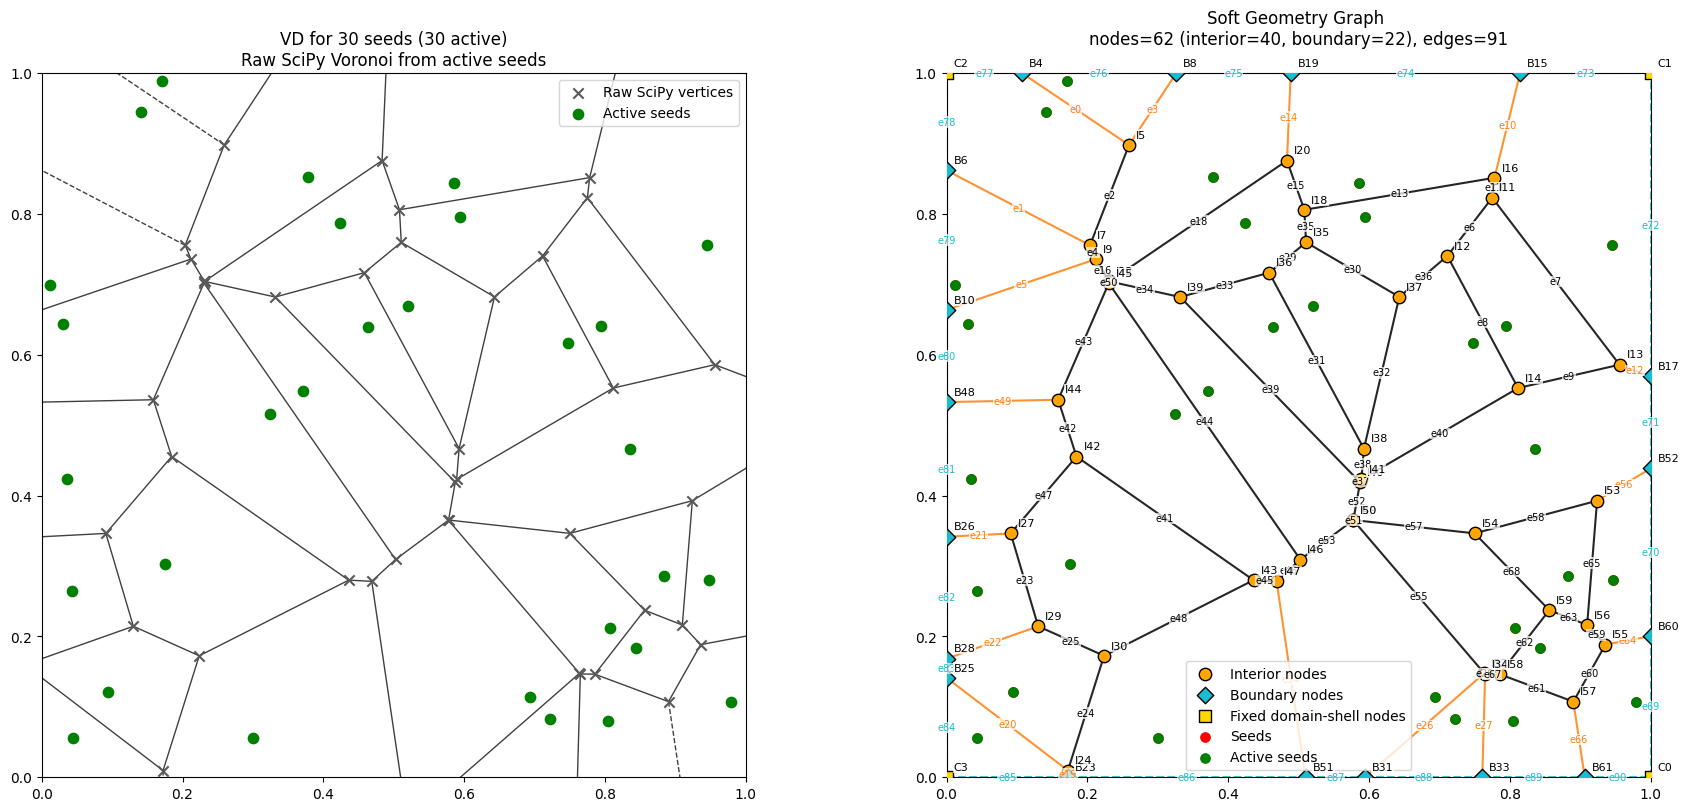

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d62c224520_2&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d62f3a07f0_3&reconnect=auto" class="pyvi…

W_raw tensor([[0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000],
        [0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
         0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000, 0.3000,
 

In [6]:
# Single Case Testing
Doit = True
if Doit:
    # Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
    u_periodic = bool(cad_domain["u_periodic"])
    v_periodic = bool(cad_domain["v_periodic"])

    dec = ContinuousVoronoiDecoder(
        Cad_domain = Face_Cad,
        face_mesh=face_mesh,
        tube_curve_samples=64,
        edge_trim_samples=32,
        tube_density_tau=0.002,
        tube_fiber_tau=0.002,
        face_u_periodic=u_periodic,
        face_v_periodic=v_periodic,
        duplicate_merge_sigma =0.05
        
    )

    edge_colors = {
        0: "black",
        1: "orange",
        2: "gray",
        3: "orange",
        4: "cyan",
    }

  
    N = 30

    # seeds = random_seeds_min_dist(
    #     N=N,
    #     min_dist=0.008,
    #     seed=i * 21,
    #     device=device,
    # ).detach().clone().requires_grad_(True)
    seeds =random_seeds_min_dist(
        N=30, min_dist=0.001, seed=21, device=device
    ).detach().clone().requires_grad_(True)

#     seeds = torch.tensor(
#     [
# [0.0052, 0.3124],
#         [0.9037, 0.1846],
#         [0.6993, 0.5881],
#         [0.0253, 0.5436],
#         [0.4556, 0.7414],
#         [0.9739, 0.9414],
#         [0.3172, 0.6292],
#         [0.4470, 0.2032],
#         [0.0937, 0.2623],
#         [0.5497, 0.5021],
#         [0.5403, 0.2796],
#         [0.3638, 0.0469],
#         [0.7338, 0.8234],
#         [0.6438, 0.7910],
#         [0.9581, 0.4708],
#     ],
#     dtype=torch.float32, device=device).detach().clone().requires_grad_(True)



    # w_raw_value = 0.0 -> core curves only.
    # Increase this, e.g. 0.5, 1.0, 2.0, to increase tube size.
    w_raw_value =0.3
    w_raw = torch.full(
        (N, N),
        w_raw_value,
        dtype=seeds.dtype,
        device=seeds.device,
    )
    generate_density_fiber = True

    out = dec(
        seeds_uv=seeds,
        w_raw=w_raw,
        generate_density_fiber=generate_density_fiber          ,
    )

    graph = out["graph"]

    loss = graph["nodes_uv"].sum()
    loss.backward()
    print("grad finite:", torch.isfinite(seeds.grad).all())

    dec.plot_scipy_vs_generated_graph(
        seeds,
        out=out,
        cad_domain=Face_Cad,
        show_node_ids=True,
        show_edge_ids=True,
        node_id_fontsize=8,
        print_node_table=False,
    )

    curves_np = out["edge_curves_xyz"].detach().cpu().numpy()
    edge_type = graph["edge_type"].detach().cpu()

    plotter = pv.Plotter()

    # For visualizing core curves, use a small display radius.
    # For physical radius from decoder, inspect out["centerline_radius"].
    display_radius = 0.01 if w_raw_value == 0.0 else float(out["centerline_radius"].detach().cpu())

    for edge_id, points in enumerate(curves_np):
        polyline = pv.PolyData(points)
        polyline.lines = np.concatenate(
            ([len(points)], np.arange(len(points)))
        ).astype(np.int64)

        tube = polyline.tube(radius=display_radius, n_sides=24)

        plotter.add_mesh(
            tube,
            color=edge_colors.get(int(edge_type[edge_id]), "gray"),
            smooth_shading=True,
        )

    plotter.show()
    print()

    if generate_density_fiber:
        # attach fiber vectors to mesh points
        xyz = face_mesh["points_xyz"]
        faces = face_mesh["pv_faces"]

        if torch.is_tensor(xyz):
            xyz = xyz.detach().cpu().numpy()
        if torch.is_tensor(faces):
            faces = faces.detach().cpu().numpy()

        mesh_vis = pv.PolyData(xyz, faces)
        fiber = out["fiber3d"].detach().cpu().numpy()
        rho = out["rho"].detach().cpu().numpy()
        mesh_vis.point_data["fiber"] = fiber
        mesh_vis.point_data["density"] = rho

        # optional: show arrows only where material exists
        mask = rho > 0.3

        fiber_pts = pv.PolyData(mesh_vis.points[mask])
        fiber_pts["fiber"] = fiber[mask]
        fiber_pts["density"] = rho[mask]

        arrows = fiber_pts.glyph(
            orient="fiber",
            scale=False  ,      # constant arrow size
            factor=0.5,      # arrow length; tune this
        )

        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh_vis,
            scalars="density",
            cmap="viridis",
            clim=[0, 1],
            opacity=1,
            smooth_shading=True,
        )

        plotter.add_mesh(
            arrows,
            color="black",
        )

        plotter.show()
        print("W_raw", w_raw)
        print("centerline_radius:", out["centerline_radius"].item())
        print("rho min/max/mean:", rho.min(), rho.max(), rho.mean())
        print("distance min/max/mean:", out["tube_distance"].min().item(), out["tube_distance"].max().item(), out["tube_distance"].mean().item())

In [7]:
Include_FEM= True
LoadingCase = "Tensile Loading"  # "Tensile" or "Compression"

voxel_size = (dx+dy+dz)/100
#fixed_height_shell= voxel_size*2
fixed_height_shell= 0.35
tangential_tol = voxel_size*0.8

if(Include_FEM):
    # ============================================================
    # Choose ONE load case below.
    # Comment out the other two sections.
    # ============================================================


    # ------------------------------------------------------------
    # 1) Tensile / Compression
    # ------------------------------------------------------------
    # Use this when you want to pull or push the shell along one axis.
    #
    # load_case:
    #   "tensile_compression", "tensile", or "compression"
    #
    # BC_dir:
    #   Axis of loading: "x", "y", or "z".
    #   The min side of this axis is fixed.
    #   The max side of this axis receives the force.
    #
    # Load_magnitude:
    #   Positive value pulls in +BC_dir direction.
    #   Negative value pushes/compresses in -BC_dir direction.
    #
    # # Example:
    shell_problem = ThickenShell(
        thickness=fixed_height_shell,
        BC_dir="y",
        Load_magnitude=1000,
        voxel_size=voxel_size,
        extra_layers=1,
        tensors=face_mesh,
        tangential_tol=tangential_tol,
        load_case="tensile_compression",
    )


    # ------------------------------------------------------------
    # 2) Three-Point Bending
    # ------------------------------------------------------------
    # Use this when you want two supports at the ends and a load in the middle.
    #
    # load_case:
    #   "three_point_bending", "threepoint_bending", or "3_point_bending"
    #
    # BC_dir:
    #   Span direction of the part.
    #   Supports are placed at min and max sides of this axis.
    #   The load is applied near the middle of this axis.
    #
    # load_dir:
    #   Direction of the bending force: "x", "y", or "z".
    #
    # Load_magnitude:
    #   Force applied at the middle.
    #   Sign controls direction along load_dir.
    #
    # load_surface_dir:
    #   Optional. Restricts the middle load nodes to one outer surface.
    #   Example: load_surface_dir="z", load_surface_side="max"
    #   means apply the middle force only on the top z surface.
    #
    # load_surface_side:
    #   "min" or "max" side of load_surface_dir.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="x",
    #     Load_magnitude=-0.01,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="three_point_bending",
    #     load_dir="z",
    #     load_surface_dir="z",
    #     load_surface_side="Max",
    # )


    # ------------------------------------------------------------
    # 3) Torsion / Twist
    # ------------------------------------------------------------
    # Use this when you want to twist the shell around one axis.
    #
    # load_case:
    #   "torsion", "twist", or "torque"
    #
    # BC_dir:
    #   Axis of twisting: "x", "y", or "z".
    #
    # fixed_side:
    #   Which end of BC_dir is fixed: "min" or "max".
    #
    # force_side:
    #   Which end receives the torque.
    #   Must be opposite to fixed_side.
    #   If omitted, the code automatically chooses the opposite side.
    #
    # Load_magnitude:
    #   Total torque magnitude.
    #   Sign controls twist direction.
    #
    # Example:
    # shell_problem = ThickenShell(
    #     thickness=fixed_height_shell,
    #     BC_dir="y",
    #     Load_magnitude=0.1,
    #     voxel_size=voxel_size,
    #     extra_layers=1,
    #     tensors=face_mesh,
    #     tangential_tol=tangential_tol,
    #     load_case="torsion",
    #     fixed_side="min",1,
    #     force_side="max",
    # )

    # shell_problem =None
    # fem =None
    fem = run_fem_loss.NeuralTOMOFEM(shell_problem, device=device, isotropic=False)
    shell_problem.debug_voxel_stats()
    loading_img = shell_problem.show_voxels_surface_and_bc(
        return_img=True,
        off_screen=True,
        window_size=(560, 430),
        show=True,
    )
else:
    shell_problem = None
    fem = None
    loading_img = None   

=== Voxel Stats ===
brep_bbox: {'xmin': -1e-07, 'xmax': 10.0000001, 'ymin': -1e-07, 'ymax': 10.0000001, 'zmin': -1e-07, 'zmax': 1e-07}
mesh: {'nelx': 54, 'nely': 54, 'nelz': 4, 'elemSize': array([0.20000001, 0.20000001, 0.20000001]), 'type': 'grid'}
elem_centers shape: (4, 54, 54, 3)
node_coords shape: (5, 55, 55, 3)
occupied voxels: 5406
total voxels: 11664
occupancy ratio: 0.463477366255144
voxels with assigned surface samples: 2601
occupied voxels with assigned surface samples: 2601
voxelized volume: 43.248003892320085
thickness: 0.35
voxel_size: 0.20000000599999995
target approx volume (sum(face_areas)*thickness): 35.0
volume ratio voxel/target: 1.2356572540662882


/home/arash/HVD_SeedsBase/neuraltomo_fem/FE.py:31: RuntimeWarning: Legacy material keys Ef/Et/nuf/nut are mapped to explicit orthotropic CCF fields. Prefer material_E1/E2/E3, material_nu12/nu23/nu13, and material_G12/G23/G13.
  self.H8 = H8_anisotropic_K(device, element_size=self.mesh.elemSize, **problem.materialProperty)


Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d62f3a1840_4&reconnect=auto" class="pyvi…

grad finite: tensor(True, device='cuda:0')


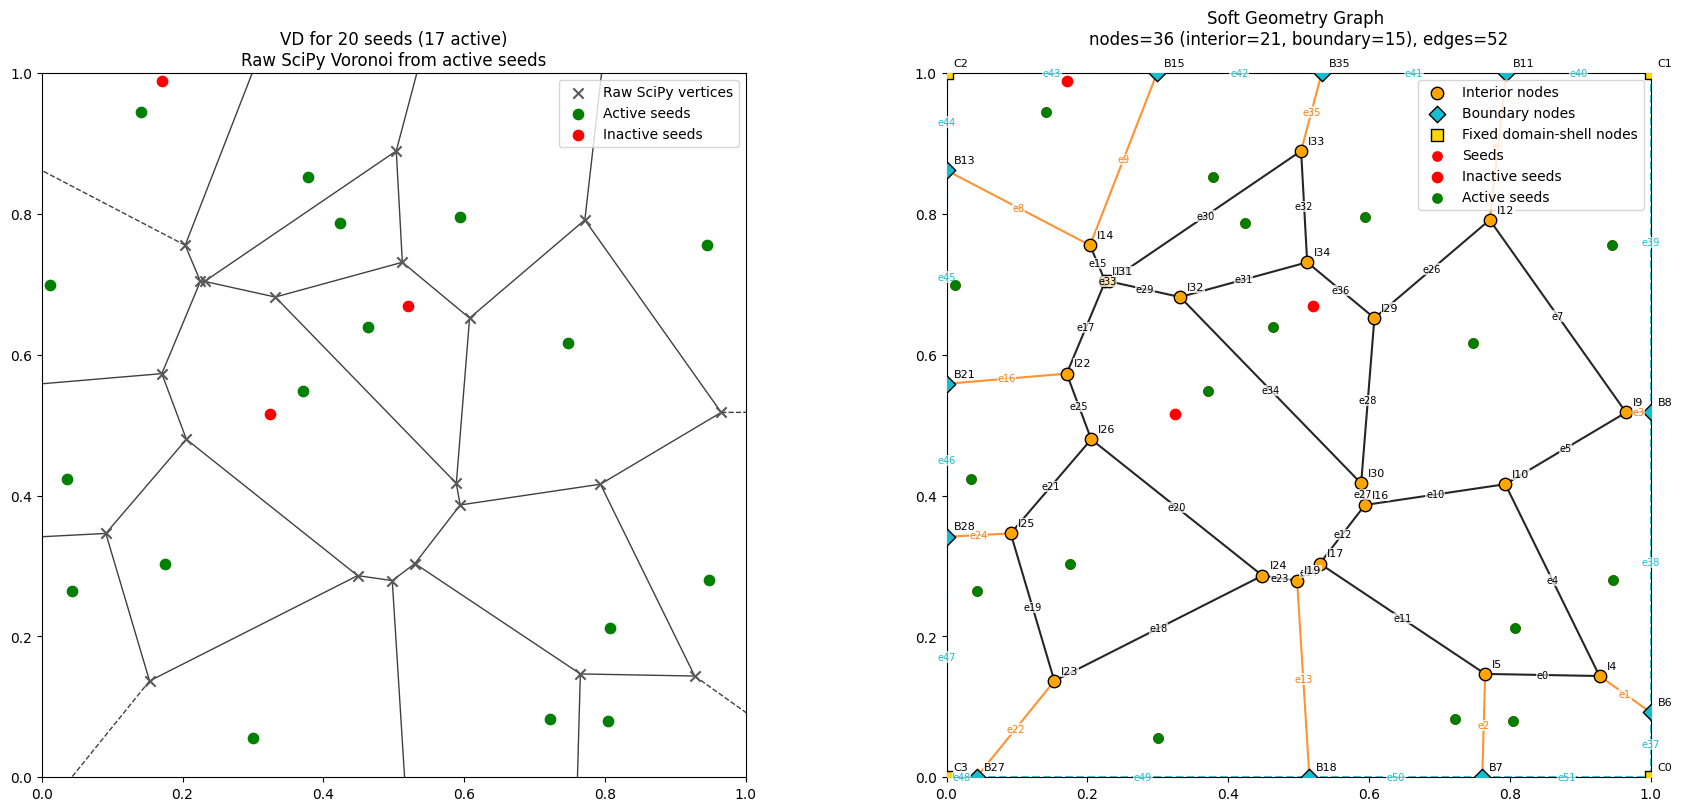

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d62f4d1960_5&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d25b5d3280_6&reconnect=auto" class="pyvi…

In [8]:
# Single Case Testing
Doit = True
if Doit:
    # Edge-type-aware UV sampling keeps shell edges on the CAD boundary.
    u_periodic = bool(cad_domain["u_periodic"])
    v_periodic = bool(cad_domain["v_periodic"])

    dec = ContinuousVoronoiDecoder(
        Cad_domain = Face_Cad,
        face_mesh=face_mesh,
        tube_curve_samples=64,
        edge_trim_samples=32,
        tube_density_tau=0.002,
        tube_fiber_tau=0.002,
        face_u_periodic=u_periodic,
        face_v_periodic=v_periodic,
        duplicate_merge_sigma =0.05,
        strut_thickness =0.5,
        
    )

    edge_colors = {
        0: "black",
        1: "orange",
        2: "gray",
        3: "orange",
        4: "cyan",
    }

  
    N = 30

    # seeds = random_seeds_min_dist(
    #     N=N,
    #     min_dist=0.008,
    #     seed=i * 21,
    #     device=device,
    # ).detach().clone().requires_grad_(True)
    seeds =random_seeds_min_dist(
        N=20, min_dist=0.001, seed=21, device=device
    ).detach().clone().requires_grad_(True)

    # seeds = torch.tensor(
    # [
    #     [0, 0],
    #     [0, 0.2],
    #     [0, 0.4],
    #     [0, 0.6],
    #     [0, 0.8],
    #     [0,1],

    # ],
    # dtype=torch.float32, device=device).detach().clone().requires_grad_(True)



    # w_raw_value = 0.0 -> core curves only.
    # Increase this, e.g. 0.5, 1.0, 2.0, to increase tube size.
    w_raw_value =0.5
    w_raw = torch.full(
        (N, N),
        w_raw_value,
        dtype=seeds.dtype,
        device=seeds.device,
    )
    generate_density_fiber = True

    out = dec(
        seeds_uv=seeds,
        w_raw=w_raw,
        generate_density_fiber=generate_density_fiber          ,
    )

    graph = out["graph"]

    loss = graph["nodes_uv"].sum()
    loss.backward()
    print("grad finite:", torch.isfinite(seeds.grad).all())

    dec.plot_scipy_vs_generated_graph(
        seeds,
        out=out,
        cad_domain=Face_Cad,
        show_node_ids=True,
        show_edge_ids=True,
        node_id_fontsize=8,
        print_node_table=False,
    )

    curves_np = out["edge_curves_xyz"].detach().cpu().numpy()
    edge_type = graph["edge_type"].detach().cpu()

    plotter = pv.Plotter()

    # For visualizing core curves, use a small display radius.
    # For physical radius from decoder, inspect out["centerline_radius"].
    display_radius = 0.01 if w_raw_value == 0.0 else float(out["centerline_radius"].detach().cpu())

    for edge_id, points in enumerate(curves_np):
        polyline = pv.PolyData(points)
        polyline.lines = np.concatenate(
            ([len(points)], np.arange(len(points)))
        ).astype(np.int64)

        tube = polyline.tube(radius=display_radius, n_sides=24)

        plotter.add_mesh(
            tube,
            color=edge_colors.get(int(edge_type[edge_id]), "gray"),
            smooth_shading=True,
        )

    plotter.show()
    print()

    if generate_density_fiber:
        # attach fiber vectors to mesh points
        xyz = face_mesh["points_xyz"]
        faces = face_mesh["pv_faces"]

        if torch.is_tensor(xyz):
            xyz = xyz.detach().cpu().numpy()
        if torch.is_tensor(faces):
            faces = faces.detach().cpu().numpy()

        mesh_vis = pv.PolyData(xyz, faces)
        fiber = out["fiber3d"].detach().cpu().numpy()
        rho = out["rho"].detach().cpu().numpy()
        mesh_vis.point_data["fiber"] = fiber
        mesh_vis.point_data["density"] = rho

        # optional: show arrows only where material exists
        mask = rho > 0.3

        fiber_pts = pv.PolyData(mesh_vis.points[mask])
        fiber_pts["fiber"] = fiber[mask]
        fiber_pts["density"] = rho[mask]

        arrows = fiber_pts.glyph(
            orient="fiber",
            scale=False  ,      # constant arrow size
            factor=0.5,      # arrow length; tune this
        )

        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh_vis,
            scalars="density",
            cmap="viridis",
            clim=[0, 1],
            opacity=1,
            smooth_shading=True,
        )

        plotter.add_mesh(
            arrows,
            color="black",
        )

        plotter.show()


In [9]:
rho_surface = out["rho"]
fiber_surface = out["fiber3d"]

# Normalize the surface fiber directions exactly like training does.
fiber_surface = fiber_surface / fiber_surface.norm(dim=1, keepdim=True).clamp_min(1e-12)

# Convert decoder surface fields to FEM element fields.
fem_fields = shell_problem.build_fem_fields_from_decoder_torch(
    rho_surface=rho_surface,
    fiber_surface=fiber_surface,
)

density_raw = fem_fields["density"].to(device=device, dtype=rho_surface.dtype)
shell_occupancy = fem_fields.get("shell_occupancy", None)
if torch.is_tensor(shell_occupancy):
    shell_occupancy = shell_occupancy.to(device=device, dtype=rho_surface.dtype).clamp(0.0, 1.0)
else:
    shell_occupancy = torch.ones_like(density_raw)

rho_fem = (shell_occupancy * density_raw.clamp(0.0, 1.0)).clamp(0.0, 1.0)

rho_min_ratio = 1.0e-5
penal = 3.0
stiffness_factor = rho_min_ratio + (1.0 - rho_min_ratio) * rho_fem.pow(penal)

phi = fem_fields["phi"].to(device=device, dtype=rho_surface.dtype)
theta = fem_fields["theta"].to(device=device, dtype=rho_surface.dtype)

# Run the same FEM call used inside Loss_FEM.
stress, compliance = fem(stiffness_factor, phi, theta, penal=1.0)

fe_solver = fem.fe
stress_field = getattr(fe_solver, "stress_vm", None)
disp_field = getattr(fe_solver, "displacement_load_dir_elem", None)
if disp_field is None:
    disp_field = getattr(fe_solver, "displacement_mag_elem", None)

loaded_disp_field = getattr(fe_solver, "displacement_load_dir_loaded_boundary", None)

max_stress = (
    stress_field.detach().reshape(-1).max()
    if torch.is_tensor(stress_field) and stress_field.numel() > 0
    else torch.tensor(float("nan"), device=device)
)

disp_for_max = loaded_disp_field
if not torch.is_tensor(disp_for_max) or disp_for_max.numel() == 0:
    disp_for_max = disp_field

max_displacement = (
    disp_for_max.detach().reshape(-1).abs().max()
    if torch.is_tensor(disp_for_max) and disp_for_max.numel() > 0
    else torch.tensor(float("nan"), device=device)
)

print("=== Surface decoder fields ===")
print("rho_surface min/max/mean:", rho_surface.min().item(), rho_surface.max().item(), rho_surface.mean().item())
print("fiber_surface shape:", tuple(fiber_surface.shape))
print("fiber norm min/max/mean:",
      fiber_surface.norm(dim=1).min().item(),
      fiber_surface.norm(dim=1).max().item(),
      fiber_surface.norm(dim=1).mean().item())

print("\n=== FEM element fields passed to solver ===")
print("rho_fem shape:", tuple(rho_fem.shape))
print("rho_fem min/max/mean:", rho_fem.min().item(), rho_fem.max().item(), rho_fem.mean().item())
print("stiffness_factor min/max/mean:",
      stiffness_factor.min().item(),
      stiffness_factor.max().item(),
      stiffness_factor.mean().item())
print("phi min/max/mean:", phi.min().item(), phi.max().item(), phi.mean().item())
print("theta min/max/mean:", theta.min().item(), theta.max().item(), theta.mean().item())

print("\n=== FEM results ===")
print("compliance:", float(compliance.detach().cpu()))
print("max stress:", float(max_stress.detach().cpu()))
print("max displacement:", float(max_displacement.detach().cpu()))

# Optional: inspect raw returned stress scalar/field too.
if torch.is_tensor(stress):
    print("returned stress min/max/mean:",
          stress.detach().min().item(),
          stress.detach().max().item(),
          stress.detach().mean().item())

# ============================================================
# Optional PyVista visualization on FEM element centers
# ============================================================
elem_centers = fem.fe.mesh.elemCenters
if torch.is_tensor(elem_centers):
    elem_centers_np = elem_centers.detach().cpu().numpy()
else:
    elem_centers_np = np.asarray(elem_centers)

rho_fem_np = rho_fem.detach().cpu().reshape(-1).numpy()
phi_np = phi.detach().cpu().reshape(-1).numpy()
theta_np = theta.detach().cpu().reshape(-1).numpy()

# Convert FEM phi/theta angles back to direction vectors for visualization.
fiber_fem_np = np.column_stack([
    np.sin(theta_np) * np.cos(phi_np),
    np.sin(theta_np) * np.sin(phi_np),
    np.cos(theta_np),
]).astype(np.float32)

pts = pv.PolyData(elem_centers_np)
pts["density"] = rho_fem_np
pts["fiber"] = fiber_fem_np

mask = rho_fem_np > 0.05
fiber_pts = pv.PolyData(elem_centers_np[mask])
fiber_pts["fiber"] = fiber_fem_np[mask]
fiber_pts["density"] = rho_fem_np[mask]

arrows = fiber_pts.glyph(
    orient="fiber",
    scale=False,
    factor=voxel_size * 2.0,
)

p = pv.Plotter()
p.add_mesh(
    pts,
    scalars="density",
    cmap="viridis",
    point_size=6,
    render_points_as_spheres=True,
    clim=[0, 1],
)
p.add_mesh(arrows, color="black")
p.show()

=== Surface decoder fields ===
rho_surface min/max/mean: 0.0 1.0 0.39585497975349426
fiber_surface shape: (35669, 3)
fiber norm min/max/mean: 1.0 1.0 1.0

=== FEM element fields passed to solver ===
rho_fem shape: (11664,)
rho_fem min/max/mean: 0.0 1.0 0.20094142854213715
stiffness_factor min/max/mean: 9.999999747378752e-06 1.0 0.1731765866279602
phi min/max/mean: -3.139218330383301 3.1415927410125732 0.7182348370552063
theta min/max/mean: 1.5707963705062866 1.5707963705062866 1.5707963705062866

=== FEM results ===
compliance: 1084.58349609375
max stress: 62773.13671875
max displacement: 1.7203232049942017
returned stress min/max/mean: 0.0003471306408755481 0.0003471306408755481 0.0003471306408755481


Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d856749360_7&reconnect=auto" class="pyvi…

In [ ]:

Explanation = "_Force_last_RDP"
Case_name = shape_path.stem
timelapse_output_folder=f"Case_Studies/{Case_name}{Explanation}"
cfg = TrainingConfig(
    LoadingCase=LoadingCase,
    # ==========================================================
    # Geometry and seed initialization
    # ==========================================================
    seed_number=30,
    min_active_seeds=10,
    possible_min_active=6,
    seed_active_baseline_strength=2.0,
    seed_active_baseline_power=2.0,
    seed_active_hard_barrier_strength=100.0,
    seed_active_hard_barrier_temperature=0.25,
    use_balanced_seed_init=True,
    seed_init_fps_seed=11,
    strut_thickness=0.4,
    Edge_in_losses="all",
    # Small-cell barrier
    # ==========================================================
    # Staged optimization
    # ==========================================================
    eps=1e-12,
    scheduler_gamma=0.5,
    grad_clip_norm=0.5,
    log_every=10,
    # ==========================================================
    # Decoder output
    # ==========================================================
    use_3d_density_filter=False,
    generate_decoder_density_fiber=True,
    # ==========================================================
    # Shared loss settings
    # ==========================================================
    lam_cell_angle_uniform=0.5,
    lam_cell_radial_uniform=0.5,
    normalize_losses=True,
    # ==========================================================
    # CVT
    # ==========================================================
    cvt_temperature=0.01,
    curve_length_tolerance=0.10,
    curve_length_outlier_weight=5.0,
    # ==========================================================
    # FEM
    # ==========================================================
    fem_max_displacement=1,
    fem_yield_strength=25e6,
    fem_constraint_power=1.1,
    fem_stress_density_threshold=1e-3,
    fem_training_safety_factor=1.0,
    fem_penal=3.0,
    fem_rho_min_ratio=1e-5,
    fem_rho_min_start=1e-3,
    fem_rho_min_end=1e-6,
    fem_density_floor=0.0,
    fem_baseline_weight=0.2,
    fem_violation_power=4.0,
    adaptive_fem_penalty=False,
    fem_lambda_initial=1.0,
    fem_lambda_min=1.0,
    fem_lambda_max=1e4,
    fem_lambda_growth=1.02,
    fem_lambda_decay=0.99,
    fem_constraint_tolerance=0.0,
    # ==========================================================
    # Invalid FEM handling
    # ==========================================================
    skip_bad_fem_steps=True,
    invalid_fem_patience=3,
    invalid_lr_factor=0.5,
    minimum_learning_rate=1e-7,
    invalid_fem_consumes_budget=True,
    debug_fem_integrity=True,
    save_fem_debug_history=True,
    # ==========================================================
    # Stage 1
    # ==========================================================
    stage1_min_steps=100,
    stage1_max_steps=300,
    stage1_patience=15,
    stage1_lam_fem=0.0,
    stage1_lam_cvt=5.0,
    stage1_lam_rep=1.0,
    stage1_lam_l_seed=1.0,
    stage1_lam_total_fiber_length=0.0,
    stage1_lam_l_curve_cell=0.10,
    stage1_scheduler_milestones=(),
    stage1_freeze_seeds=False,
    stage1_allow_seed_outside_domain=False,
    stage1_min_delta_abs=1e-4,
    stage1_min_delta_rel=1e-3,
    # ==========================================================
    # Stage 2
    # ==========================================================
    stage2_min_steps=100,
    stage2_max_steps=300,
    stage2_patience=2000,
    stage2_lam_fem=2.0,
    stage2_lam_cvt=0.1,
    stage2_lam_rep=0,
    stage2_lam_l_seed=1.0,
    stage2_lam_l_curve_cell=0,
    stage2_scheduler_milestones=(0.90,),
    stage2_lam_total_fiber_length=2.0,
    stage2_freeze_seeds=False,
    stage2_allow_seed_outside_domain=False,
    stage2_min_delta_abs=1e-4,
    stage2_min_delta_rel=1e-3,
    # ==========================================================
    # Adaptive stage controller
    # ==========================================================
    stage_topology_grace_steps=10,
    stage_topology_grace_max_resets=2,
    restore_transition_checkpoint=True,
    reset_optimizer_between_stages=True,
    stage_transition_selection="next_stage_objective",
    debug_stage_controller=False,
    # ==========================================================
    # Learning rates
    # ==========================================================
    lr_seed_refine=1e-4,
    lr_independent_seed_offsets=1e-5,
    lr_delta_head=1e-4,
    lr_mlp=1e-4,
    lr_decoder=1e-4,
    # ==========================================================
    # Seed movement
    # ==========================================================
    use_independent_seed_offsets=True,
    seed_offset_scale_start=0.2,
    seed_offset_scale_final=0.1,
    seed_offset_scale_ramp_frac=0.80,
    use_rolling_seed_anchors=True,
    seed_anchor_warmup_frac=0.05,
    seed_anchor_momentum=0.10,
    anchor_guard_updates=False,
    disable_rolling_seed_anchors_for_curve_only=False,
    # ==========================================================
    # Logging
    # ==========================================================
    tensorboard_enabled=True,
    tensorboard_log_root="runs",
    experiment_name=f"{Case_name}{Explanation}",
    MakeTimelaps=True,
    timelapse_output_folder=timelapse_output_folder,
)


trainer = NN_Trainer(
    generator=Face_Cad,
    viz=viz,
    decoder_cls=ContinuousVoronoiDecoder,
    ppnet_cls=PPNet,
    fem=fem,
    shell_problem=shell_problem,
    config=cfg,
    face_mesh=face_mesh,
)

result = trainer.train(
    shape_path=shape_path,
    face_tensors=[face_mesh],
)

print("best step:", result["best_step"])
print("best score:", result["best_score"])
print("density:", result["Final_shape_density"].shape)
print("fiber:", result["Final_shape_fiber_direction"].shape)
print("seed UV:", result["best_seed_points_uv"].shape)
print("seed XYZ:", result["best_seed_points_xyz"].shape)

TensorBoard log dir: runs/Planar_Force_last_RDP
Invalid FEM attempts consume global budget: True
Decoder trainable parameters: none


Training:   0%|          | 0/600 [00:00<?, ?it/s]

[L-total improvement] New best_step=0 | L_total=5.132766 | best_active_units=30.0 | VolFrac=0.000000 | L(min/max/ratio)=2.602650e-02/3.192408e+00/122.66
Stage 1 finished at local step 114 (global step 113) | reason=patience
    best_raw: next_stage_monitor=1.214073e-01
    last: next_stage_monitor=1.214073e-01
Stage 1 completed | reason=patience | local_steps=114 | best_local_step=113 | best_monitor=4.707417e+00 | best_raw_step=113 | last_valid_step=113 | transition_checkpoint=best_raw | transition_score=1.214073e-01 | optimizer_reset=True
[Stage transition] Restored Stage 1 topology checkpoint at global_step=113
Selected transition checkpoint: best_raw
[Checkpoint reset] Reset physical checkpoint trackers for Stage 2
Stage 2 completed | reason=max_steps | local_steps=300
Stage 2 completed | reason=max_steps | local_steps=300 | best_local_step=0 | best_monitor=2.446642e+01 | best_raw_step=0 | last_valid_step=299 | transition_checkpoint=None | transition_score=inf | optimizer_reset=True

3D density volume fraction (area-weighted): 0.383083


Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d1c0426b90_8&reconnect=auto" class="pyvi…

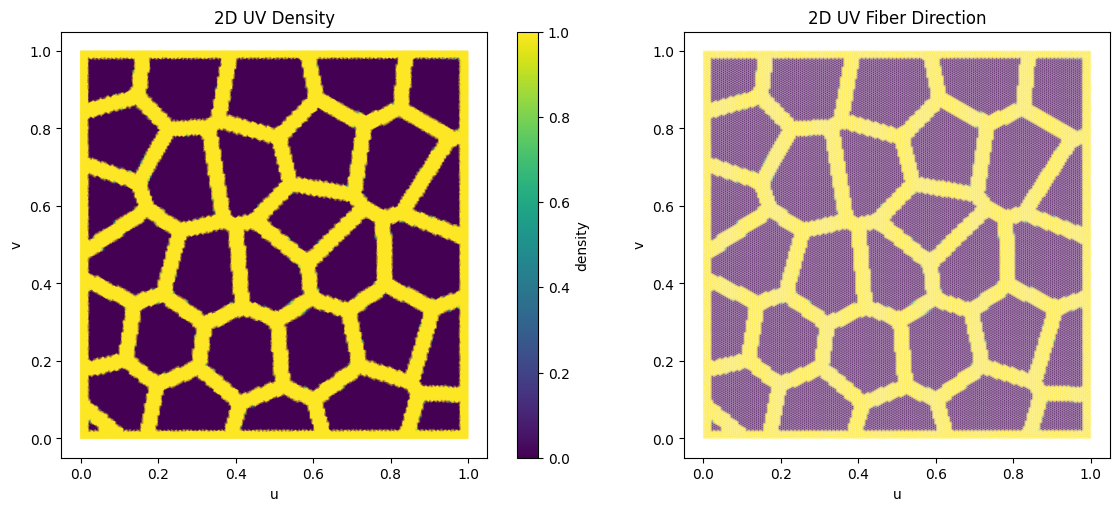

In [11]:
from Training.MainTrain import (
    load_optimized_shell_function,
    evaluate_optimized_shell_function,
    visualize_optimized_shell_fields,
)

path = result["optimized_function_path"]
opt_fn = load_optimized_shell_function(path, device="cuda")
fields = evaluate_optimized_shell_function(opt_fn)

vis = visualize_optimized_shell_fields(
    fields,
    show_2d=True,
    show_3d=True,
    fiber_stride=30,
    fiber_min_density=0.2,
    show_fiber_background=True,
)

vis["plotter"].show()

In [12]:

def to_np(x):
    if x is None:
        return None
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)
edge_colors = {
    0: "black",
    1: "orange",
    2: "gray",
    3: "orange",
    4: "cyan",
}
points_xyz = to_np(face_mesh["points_xyz"])
faces = to_np(face_mesh["faces_ijk"]).astype(int)
curves_xyz = to_np(result["best_edge_curves_xyz"])
edge_type = to_np(result["best_edge_type"])
seeds_xyz = to_np(result["best_seed_points_xyz"])

pv_faces = np.hstack([
    np.full((faces.shape[0], 1), 3, dtype=np.int64),
    faces.astype(np.int64),
]).ravel()

plotter = pv.Plotter()
surf = pv.PolyData(points_xyz, pv_faces)
plotter.add_mesh(surf, color="white", opacity=0.25, show_edges=False)

tube_radius = 0.075  # adjust if too thin/thick

for edge_id, c in enumerate(curves_xyz):
    if c.shape[0] < 2:
        continue
    line = pv.PolyData(c.astype(np.float32))
    line.lines = np.hstack([[c.shape[0]], np.arange(c.shape[0])]).astype(np.int64)
    tube = line.tube(radius=tube_radius, n_sides=12)
    plotter.add_mesh(tube, color=edge_colors.get(int(edge_type[edge_id]), "gray"), smooth_shading=True)

if seeds_xyz is not None:
    plotter.add_mesh(
        pv.PolyData(seeds_xyz.astype(np.float32)),
        color="red",
        point_size=10,
        render_points_as_spheres=True,
    )
plotter.add_axes()
plotter.show()

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71dbacd5a8c0_9&reconnect=auto" class="pyvi…

In [13]:
trainer.visualize_result_final(
    result=result,
    points_xyz=face_mesh["points_xyz"],
    faces_ijk=face_mesh["faces_ijk"],
    thr=0.5,
    show_solid=True ,
    show_rho_overlay=False,
)

Widget(value='<iframe src="http://localhost:43085/index.html?ui=P_0x71d1b1fa91b0_10&reconnect=auto" class="pyv…

(PolyData (0x71d192f18ee0)
   N Cells:    27333
   N Points:   35669
   N Strips:   0
   X Bounds:   0.000e+00, 1.000e+01
   Y Bounds:   0.000e+00, 1.000e+01
   Z Bounds:   0.000e+00, 0.000e+00
   N Arrays:   0,
 0.5)